# Previsão de chuva a partir de dados históricos de clima

**Pergunta do projeto:** usando as condições meteorológicas de hoje, é possível prever se choverá amanhã?

Este notebook parte do CSV já tabulado (`input_modelo.csv`), gerado a partir da API histórica da Open-Meteo para São Paulo (2015–2025), e contém:

1. Dicionário de dados;
2. Carregamento e checagem rápida de qualidade;
3. Criação da variável-alvo (`choveu_amanha`);
4. Um modelo de classificação simples (Regressão Logística);
5. Avaliação do modelo.

Bora destrinchar sem código, só o raciocínio por trás de cada passo.

**1. O problema: transformar "prever chuva" em uma pergunta de sim/não**

Machine learning de classificação precisa de uma pergunta binária clara: *"amanhã vai chover ou não?"* (1 = sim, 0 = não). Só que seus dados originais trazem `precipitation_sum` (quantos mm choveu naquele dia), um número contínuo, não um sim/não. Então o primeiro passo foi **transformar o problema**: escolhi um limiar (1mm) — abaixo disso é garoa/não conta, acima disso é "choveu de verdade".

**2. O truque do "amanhã": olhar pra trás no tempo**

Aqui está o pulo do gato de todo o projeto: eu quero prever o futuro usando o presente. Então, para cada linha (dia), eu preciso saber: *"o que aconteceu no dia seguinte a este?"*

A técnica é pegar a coluna "choveu hoje" e **deslocá-la um dia para trás** (`shift(-1)`). Na prática:

| Dia | choveu_hoje | choveu_amanha (=choveu_hoje do dia seguinte) |
|---|---|---|
| 01/jan | 0 | 1 (porque no dia 02 choveu) |
| 02/jan | 1 | 0 |
| 03/jan | 0 | ... |

Assim, a linha do dia 01/jan carrega tanto "como estava o tempo hoje" (as features) quanto "o que aconteceu amanhã" (o alvo) — que é exatamente o que o modelo precisa para aprender a relação causa→efeito.

O último dia do dataset fica sem "amanhã" (não sabemos o que aconteceu depois de 31/12), então essa linha é descartada.

**3. Features: o que o modelo pode "olhar" para decidir**

São as 11 variáveis meteorológicas *do dia atual* (temperatura, umidade, nuvens, pressão, chuva, vento, radiação, sol). A ideia física por trás: ar úmido + muita nuvem + pressão caindo geralmente antecede chuva. O modelo não sabe disso de antemão — ele vai descobrir esses padrões sozinho, olhando os dados históricos.

**4. Por que separar treino e teste**

Se eu treinasse e testasse com os mesmos dados, o modelo poderia simplesmente "decorar" os exemplos em vez de aprender o padrão geral — aí ele pareceria ótimo mas falharia com dias novos. Por isso separo 80% para o modelo aprender e escondo 20% para testar depois, como uma prova que ele nunca viu.

**5. Por que padronizar os dados (StandardScaler)**

Pressão fica em torno de 1000 e umidade vai de 0 a 100 — escalas bem diferentes. Sem padronizar, a Regressão Logística pode achar erroneamente que pressão "importa mais" só porque os números dela são maiores. Padronizar coloca todo mundo na mesma régua (média 0, desvio 1) antes de comparar.

**6. Por que Regressão Logística**

É o modelo mais simples e didático pra classificação binária: ele soma cada variável multiplicada por um "peso" e passa isso por uma função que converte o resultado numa probabilidade entre 0 e 1 (chance de chover). Se a probabilidade > 50%, ele prevê "vai chover". É fácil de interpretar os pesos depois (o gráfico de coeficientes que te mostrei).

**7. Por que comparar com o "baseline"**

Se 57% dos dias historicamente não chove, um modelo preguiçoso que sempre chuta "não vai chover" já acerta 57% sem aprender nada. Por isso a métrica que importa não é a acurácia sozinha (75%), mas **quanto ela supera esse chute preguiçoso** (+18 pontos) — isso sim prova que o modelo está captando um padrão real.

**8. Matriz de confusão e classification report**

Acurácia geral esconde detalhes: o modelo pode estar ótimo prevendo "não chove" e péssimo prevendo "chove". A matriz de confusão mostra os 4 cenários possíveis (acertou chuva, acertou sol, previu chuva errado, previu sol errado) separadamente, pra você enxergar onde ele erra mais.

Se quiser, posso desenhar um diagrama visual desse fluxo (dado → shift → target → treino/teste → modelo → previsão) pra ficar ainda mais fácil de visualizar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Dicionário de dados

| Coluna | Tipo | Unidade | Descrição | Origem |
|---|---|---|---|---|
| `time` | data (`datetime64`) | AAAA-MM-DD | Data de referência do registro diário | API (bruto) |
| `temperature_2m_max` | float | °C | Temperatura máxima do dia, medida a 2 m de altura | API (bruto) |
| `temperature_2m_min` | float | °C | Temperatura mínima do dia | API (bruto) |
| `temperature_2m_mean` | float | °C | Temperatura média do dia | API (bruto) |
| `relative_humidity_2m_mean` | int | % | Umidade relativa média do ar no dia | API (bruto) |
| `cloud_cover_mean` | int | % | Cobertura média de nuvens no dia | API (bruto) |
| `pressure_msl_mean` | float | hPa | Pressão atmosférica média ao nível do mar | API (bruto) |
| `precipitation_sum` | float | mm | Total de precipitação (chuva) acumulada no dia | API (bruto) |
| `precipitation_hours` | float | h | Número de horas do dia com precipitação | API (bruto) |
| `wind_speed_10m_max` | float | km/h | Velocidade máxima do vento a 10 m de altura | API (bruto) |
| `shortwave_radiation_sum` | float | MJ/m² | Radiação solar total recebida no dia | API (bruto) |
| `sunshine_duration` | float | s | Duração total de insolação (sol) no dia | API (bruto) |
| `choveu_hoje` | int (0/1) | binário | 1 se `precipitation_sum` do próprio dia ultrapassou o limiar definido, 0 caso contrário | Derivada |
| `choveu_amanha` | int (0/1) | binário — **alvo** | 1 se choveu no dia seguinte, 0 caso contrário. É o que o modelo vai prever | Derivada (target) |

> Dados de **reanálise** (observações + modelos meteorológicos combinados), não medições diretas de uma única estação.

## 2. Carregando os dados

In [2]:
df = pd.read_csv("input_modelo.csv")
df["time"] = pd.to_datetime(df["time"])

print("Dimensão:", df.shape)
print("Período:", df["time"].min().date(), "até", df["time"].max().date())
df.head()

Dimensão: (4018, 12)
Período: 2015-01-01 até 2025-12-31


,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,cloud_cover_mean,pressure_msl_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,shortwave_radiation_sum,sunshine_duration
0,2015-01-01,31.5,21.8,26.3,72,74,1012.4,0.3,1.0,19.9,29.60,47560.45
1,2015-01-02,30.9,22.2,25.9,75,65,1012.8,7.8,6.0,20.9,26.71,47593.65
2,2015-01-03,25.0,21.4,22.8,92,93,1015.6,5.7,11.0,16.3,18.41,34175.66
3,2015-01-04,25.6,21.2,22.7,89,95,1016.7,20.9,12.0,14.6,16.83,28601.84
4,2015-01-05,25.1,20.3,22.1,90,92,1017.1,5.9,7.0,14.6,13.23,26341.95


### Checagem rápida de qualidade

In [3]:
print("Datas duplicadas:", df["time"].duplicated().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print("\nValores ausentes por coluna:")
print(df.isna().sum())

Datas duplicadas: 0
Linhas duplicadas: 0

Valores ausentes por coluna:
time                         0
temperature_2m_max           0
temperature_2m_min           0
temperature_2m_mean          0
relative_humidity_2m_mean    0
cloud_cover_mean             0
pressure_msl_mean            0
precipitation_sum            0
precipitation_hours          0
wind_speed_10m_max           0
shortwave_radiation_sum      0
sunshine_duration            0
dtype: int64


## 3. Criando a variável-alvo: vai chover amanhã?

- Definimos um limiar de chuva (mm) para considerar que "choveu de fato" no dia;
- Criamos `choveu_hoje` comparando `precipitation_sum` com esse limiar;
- Criamos `choveu_amanha` deslocando essa coluna um dia para trás (`shift(-1)`), para alinhar o resultado do dia seguinte à linha de hoje;
- Descartamos a última linha, que fica sem "amanhã" conhecido.

In [4]:
LIMIAR_CHUVA_MM = 1.0  # a partir de 1mm no dia consideramos que choveu

df["choveu_hoje"] = (df["precipitation_sum"] >= LIMIAR_CHUVA_MM).astype(int)
df["choveu_amanha"] = df["choveu_hoje"].shift(-1)
df = df.dropna(subset=["choveu_amanha"]).copy()
df["choveu_amanha"] = df["choveu_amanha"].astype(int)

df[["time", "precipitation_sum", "choveu_hoje", "choveu_amanha"]].head(10)

,time,precipitation_sum,choveu_hoje,choveu_amanha
0,2015-01-01,0.3,0,1
1,2015-01-02,7.8,1,1
2,2015-01-03,5.7,1,1
3,2015-01-04,20.9,1,1
4,2015-01-05,5.9,1,1
5,2015-01-06,10.3,1,1
6,2015-01-07,7.6,1,1
7,2015-01-08,1.5,1,0
8,2015-01-09,0.5,0,1
9,2015-01-10,1.4,1,1


### Balanceamento das classes

Vale checar a proporção de dias com e sem chuva no dia seguinte antes de treinar o modelo.

Proporção da variável-alvo:
choveu_amanha
0    0.573
1    0.427
Name: proportion, dtype: float64


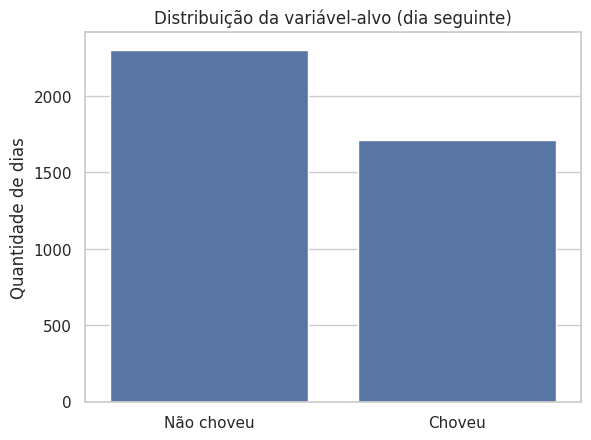

In [5]:
proporcao = df["choveu_amanha"].value_counts(normalize=True)
print("Proporção da variável-alvo:")
print(proporcao.round(3))

sns.countplot(data=df, x="choveu_amanha")
plt.xticks([0, 1], ["Não choveu", "Choveu"])
plt.title("Distribuição da variável-alvo (dia seguinte)")
plt.xlabel("")
plt.ylabel("Quantidade de dias")
plt.show()

## 4. Selecionando as variáveis explicativas (features)

Usamos as condições meteorológicas **do próprio dia** para prever a chuva **do dia seguinte**.

In [6]:
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "pressure_msl_mean",
    "precipitation_sum",
    "precipitation_hours",
    "wind_speed_10m_max",
    "shortwave_radiation_sum",
    "sunshine_duration",
]

X = df[features]
y = df["choveu_amanha"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (4017, 11)
Formato de y: (4017,)


## 5. Dividindo em treino e teste

`test_size=0.2` (20% para teste), `random_state=42` para reprodutibilidade, e `stratify=y` para manter a mesma proporção de dias com/sem chuva nos dois conjuntos.

> Como esses dados são uma série temporal, uma alternativa mais rigorosa seria treinar com os anos mais antigos e testar com os mais recentes. Para este primeiro modelo simples, a divisão aleatória estratificada já é suficiente.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (3213, 11) | Teste: (804, 11)


## 6. Treinando um modelo simples: Regressão Logística

Padronizamos as variáveis com `StandardScaler` antes de treinar, já que elas têm escalas bem diferentes (pressão ~1000, umidade 0–100, chuva 0 a dezenas de mm).

In [8]:
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_escalado, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 7. Avaliando o modelo

- **Acurácia** do modelo vs. **baseline** (chute fixo na classe mais comum);
- **Matriz de confusão**;
- **Relatório de classificação** (`precision`, `recall`, `f1-score`).

In [9]:
y_pred = modelo.predict(X_test_escalado)

acuracia = accuracy_score(y_test, y_pred)
baseline = y_test.value_counts(normalize=True).max()

print(f"Acurácia do modelo:  {acuracia:.2%}")
print(f"Baseline (chute fixo na classe mais comum): {baseline:.2%}")
print(f"Ganho sobre o baseline: {(acuracia - baseline)*100:.1f} pontos percentuais")

Acurácia do modelo:  75.75%
Baseline (chute fixo na classe mais comum): 57.34%
Ganho sobre o baseline: 18.4 pontos percentuais


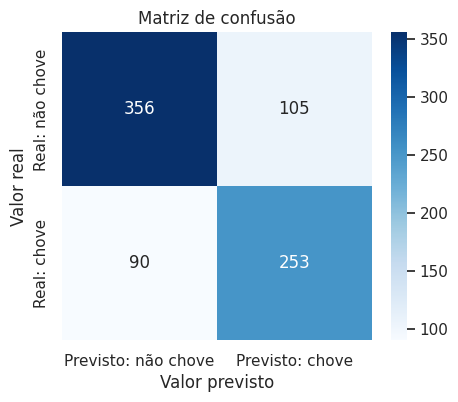

              precision    recall  f1-score   support

  Não choveu       0.80      0.77      0.79       461
      Choveu       0.71      0.74      0.72       343

    accuracy                           0.76       804
   macro avg       0.75      0.75      0.75       804
weighted avg       0.76      0.76      0.76       804



In [10]:
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Previsto: não chove", "Previsto: chove"],
    yticklabels=["Real: não chove", "Real: chove"],
)
plt.title("Matriz de confusão")
plt.ylabel("Valor real")
plt.xlabel("Valor previsto")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Não choveu", "Choveu"]))

## 8. Quais variáveis mais pesam na decisão do modelo?

Como usamos Regressão Logística sobre dados padronizados, os coeficientes indicam a força e a direção (positiva = aumenta a chance de chuva, negativa = reduz) de cada variável.

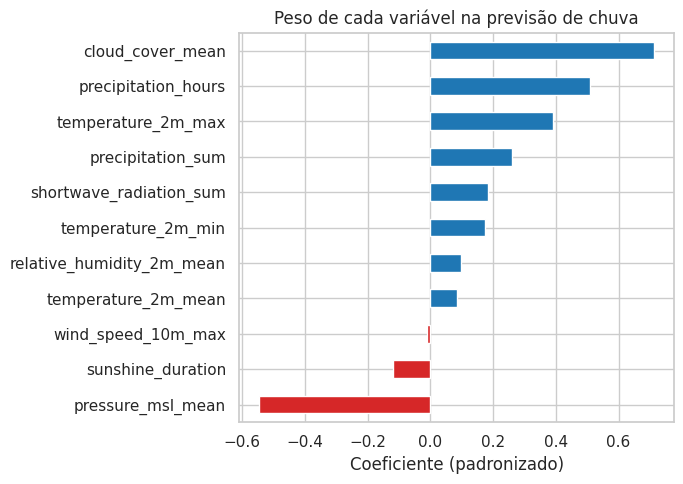

cloud_cover_mean             0.713685
precipitation_hours          0.508604
temperature_2m_max           0.389519
precipitation_sum            0.261485
shortwave_radiation_sum      0.185031
temperature_2m_min           0.174875
relative_humidity_2m_mean    0.097133
temperature_2m_mean          0.083725
wind_speed_10m_max          -0.010873
sunshine_duration           -0.120112
pressure_msl_mean           -0.546604
dtype: float64

In [11]:
coeficientes = pd.Series(modelo.coef_[0], index=features).sort_values()

plt.figure(figsize=(7, 5))
coeficientes.plot(kind="barh", color=["#d62728" if v < 0 else "#1f77b4" for v in coeficientes])
plt.title("Peso de cada variável na previsão de chuva")
plt.xlabel("Coeficiente (padronizado)")
plt.tight_layout()
plt.show()

coeficientes.sort_values(ascending=False)

## 9. Testando o modelo com um dia hipotético

Simulando um dia bem nublado, úmido e com pressão baixa (condições que fisicamente favorecem chuva).

In [12]:
dia_hipotetico = pd.DataFrame([{
    "temperature_2m_max": 22.0,
    "temperature_2m_min": 18.0,
    "temperature_2m_mean": 20.0,
    "relative_humidity_2m_mean": 92,
    "cloud_cover_mean": 95,
    "pressure_msl_mean": 1008.0,
    "precipitation_sum": 5.0,
    "precipitation_hours": 4.0,
    "wind_speed_10m_max": 25.0,
    "shortwave_radiation_sum": 10.0,
    "sunshine_duration": 5000.0,
}])[features]

dia_hipotetico_escalado = scaler.transform(dia_hipotetico)
previsao = modelo.predict(dia_hipotetico_escalado)[0]
probabilidade = modelo.predict_proba(dia_hipotetico_escalado)[0][1]

print("Previsão:", "Vai chover amanhã" if previsao == 1 else "Não vai chover amanhã")
print(f"Probabilidade estimada de chuva: {probabilidade:.1%}")

Previsão: Vai chover amanhã
Probabilidade estimada de chuva: 81.2%


## 10. Conclusões e próximos passos

- O modelo (Regressão Logística simples) supera claramente o baseline ingênuo, mostrando que existe sinal preditivo nas condições do dia atual para prever a chuva do dia seguinte.
- Ainda assim, é um modelo **simples**: com poucas variáveis e sem memória de dias anteriores além do próprio dia.
- Possíveis melhorias para uma próxima iteração:
    - testar outros modelos (`DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoosting`);
    - incluir variáveis de "memória", como chuva e pressão dos últimos 2–3 dias (médias móveis);
    - incluir sazonalidade (mês/estação do ano);
    - fazer a divisão treino/teste **cronológica** (treinar no passado, testar no futuro), mais realista para séries temporais;
    - ajustar o limiar de chuva (`LIMIAR_CHUVA_MM`) e observar o impacto nas métricas;
    - usar validação cruzada em vez de uma única divisão treino/teste.